In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [39]:
data = pd.read_excel('titanic.xls')

In [10]:
# verifier la dimension de notre fichier
data.shape

(1309, 14)

In [12]:
#  voir nos 14 colonn
data.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

In [40]:
# affciher les 5 premieres lignes de notre data
data.head(6)
# lead

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,3,NaN,"New York, NY"


In [41]:
# supprimons les inforations non importante

data = data.drop(["name", "sibsp", "parch", "ticket", "fare", "cabin", "embarked", "boat", "body","home.dest"], axis=1)
data.head()

,pclass,survived,sex,age
0,1,1,female,29.0000
1,1,1,male,0.9167
2,1,0,female,2.0000
3,1,0,male,30.0000
4,1,0,female,25.0000


In [42]:
# desterminons les statistiques de base pour chaque colonne
data.describe()

,pclass,survived,age
count,1309.000000,1309.000000,1046.000000
mean,2.294882,0.381971,29.881135
std,0.837836,0.486055,14.413500
min,1.000000,0.000000,0.166700
25%,2.000000,0.000000,21.000000
50%,3.000000,0.000000,28.000000
75%,3.000000,1.000000,39.000000
max,3.000000,1.000000,80.000000


In [43]:
# apres avoir remarquer que notre tableau contient au niveau de age des valeurs manquantes 
# on fait le choix de  supprimestoutes les lignes correspondantes  plutot que de les remplacer par des valeurs par defaut.

data = data.dropna(axis=0)
data.describe()

,pclass,survived,age
count,1046.000000,1046.000000,1046.000000
mean,2.207457,0.408222,29.881135
std,0.841497,0.491740,14.413500
min,1.000000,0.000000,0.166700
25%,1.000000,0.000000,21.000000
50%,2.000000,0.000000,28.000000
75%,3.000000,1.000000,39.000000
max,3.000000,1.000000,80.000000


In [45]:
# values_count,pour savoir le nombre de personne par classe(targets)

data['pclass'].value_counts()

pclass
3    501
1    284
2    261
Name: count, dtype: int64

<Axes: xlabel='pclass'>

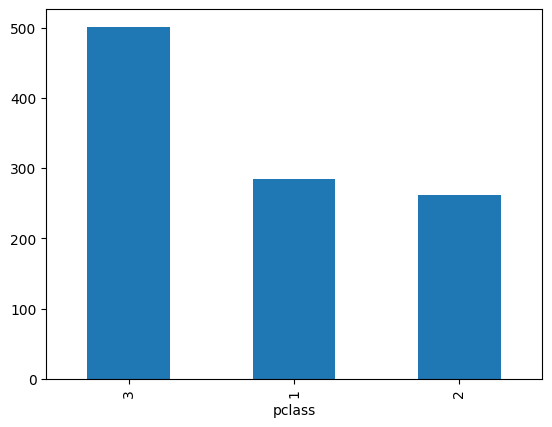

In [31]:
# graphe bar , nous permet de voir la classe qui contient le plus de personne
data['pclass'].value_counts().plot.bar()


<Axes: ylabel='Frequency'>

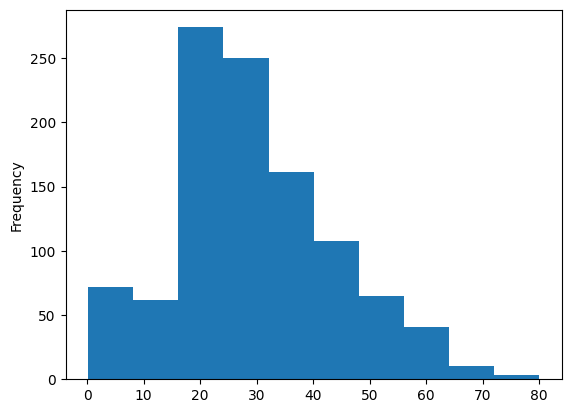

In [33]:
# repartition des ages selon un histogramme
data['age'].plot.hist()


In [47]:
# groupby() permet de regrouper les donnees selon un parametre, cependant il faut juste apres appliquer une mehtode 
# statistique

data.groupby(['sex','pclass']).mean()

survived        age
sex    pclass                     
female 1       0.962406  37.037594
       2       0.893204  27.499191
       3       0.473684  22.185307
male   1       0.350993  41.029250
       2       0.145570  30.815401
       3       0.169054  25.962273

# EXERCICE


In [48]:
data.loc[data['age'] <= 20 , ["age"]] = 0
data.loc[(data['age'] > 20) & (data['age'] <= 30), ["age"] ] = 1
data.loc[(data['age'] > 30) & (data['age'] <= 40), ["age"]]  = 2
data.loc[data['age'] > 40, ["age"]]  = 3


In [49]:
data["age"].value_counts()

age
1.0    361
0.0    248
3.0    227
2.0    210
Name: count, dtype: int64

<Axes: xlabel='age'>

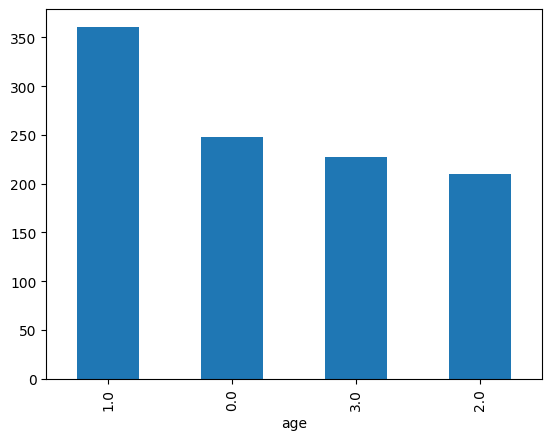

In [64]:
data['age'].value_counts().plot.bar()

In [67]:
data.groupby(["age"]).mean

<bound method GroupBy.mean of <pandas.core.groupby.generic.DataFrameGroupBy object at 0x0000019FEEC040E0>>